In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Install
!pip install osmnx geopandas

import osmnx as ox
import geopandas as gpd

# Download road network for Oakland and Berkeley
graph = ox.graph_from_place(["Oakland, California, USA", "Berkeley, California, USA"], network_type="drive")

# Convert to GeoDataFrame
edges = ox.graph_to_gdfs(graph, nodes=False)

# Check what columns you have
print(edges.columns.tolist())
print(edges['highway'].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.2 MB/s eta 0:00:00
['osmid', 'bridge', 'highway', 'lanes', 'maxspeed', 'oneway', 'reversed', 'length', 'geometry', 'name', 'ref', 'tunnel', 'junction', 'access', 'width']
highway
residential                        19028
tertiary                            3632
secondary                           3315
primary                             1031
motorway_link                        354
unclassified                         278
motorway                             211
secondary_link                       108
primary_link                          58
tertiary_link                         50
living_street                         10
[unclassified, residential]            4
[residential, unclassified]            4
[living_street, residential]           2
[secondary_link, motorway_link]        2
trunk                                  2
[motorway_link, motorway]              1
[primary, motorway]                    1
[primary, motorway_lin

# Length of Major and Minor Road in 400m buffer

In [2]:
import pandas as pd
import numpy as np

DATA_FOLDER_PATH = "/content/drive/MyDrive/255 Final Project/Data/"
STATIONS24_PATH = DATA_FOLDER_PATH + "cleaned/stations24_clustered.geojson"

# Classify roads - handle both string and list values
major_types = {'motorway', 'trunk', 'primary', 'secondary',
               'motorway_link', 'primary_link', 'secondary_link'}
minor_types = {'tertiary', 'residential', 'unclassified',
               'living_street', 'tertiary_link'}

def classify_road(highway_val):
    # Handle cases where highway is a list
    if isinstance(highway_val, list):
        highway_val = highway_val[0]
    if highway_val in major_types:
        return 'major'
    elif highway_val in minor_types:
        return 'minor'
    else:
        return 'other'

edges['road_class'] = edges['highway'].apply(classify_road)

# Make sure both are in the same CRS
stations = gpd.read_file(STATIONS25_PATH).to_crs("EPSG:32610")
edges = edges.to_crs("EPSG:32610")

# Buffer stations by 400m
stations['buffer'] = stations.geometry.buffer(400)
stations_buffered = stations.set_geometry('buffer')

# For each station, calculate major and minor road length
results = []
for idx, station in stations.iterrows():
    buf = station['buffer']
    clipped = edges[edges.geometry.intersects(buf)].copy()
    clipped['geometry'] = clipped.geometry.intersection(buf)

    major_len = clipped[clipped['road_class'] == 'major']['geometry'].length.sum()
    minor_len = clipped[clipped['road_class'] == 'minor']['geometry'].length.sum()

    results.append({
        'station_id': station['id'],  # adjust to your column name
        'combined_count': station['combined_count'],
        'cluster': station['cluster'],
        'major_road_length_m': major_len,
        'minor_road_length_m': minor_len
    })

road_df = pd.DataFrame(results)
road_df.head(50)

NameError: name 'edges' is not defined

In [ ]:
road_df0 = road_df[road_df['cluster'] == 0]
road_df1 = road_df[road_df['cluster'] == 1]
road_df2 = road_df[road_df['cluster'] == 2]
road_df3 = road_df[road_df['cluster'] == 3]

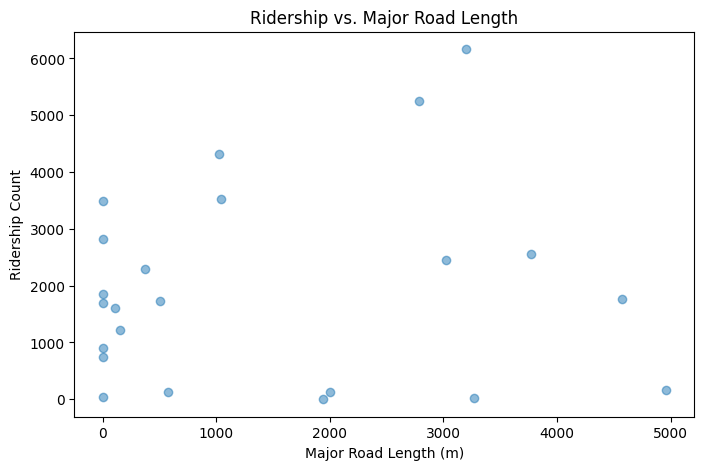

In [ ]:
import matplotlib.pyplot as plt

# cluster 0 major road length
plt.figure(figsize=(8, 5))
plt.scatter(road_df0['major_road_length_m'], road_df0['combined_count'], alpha=0.5)
plt.xlabel('Major Road Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Major Road Length')
plt.show()

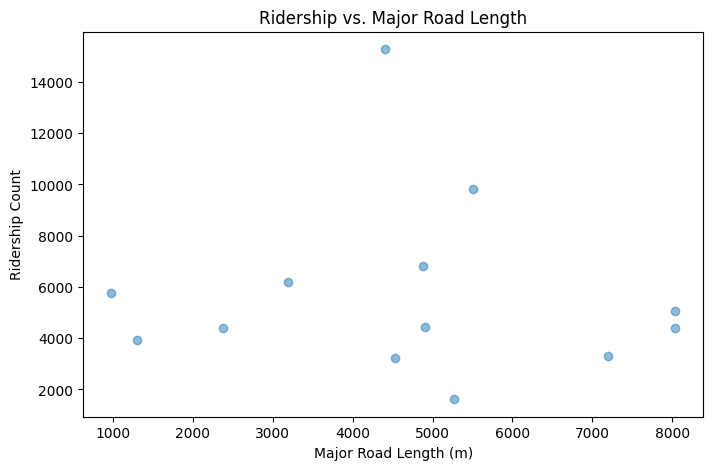

In [ ]:
# cluster 1 major road length
plt.figure(figsize=(8, 5))
plt.scatter(road_df1['major_road_length_m'], road_df1['combined_count'], alpha=0.5)
plt.xlabel('Major Road Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Major Road Length')
plt.show()

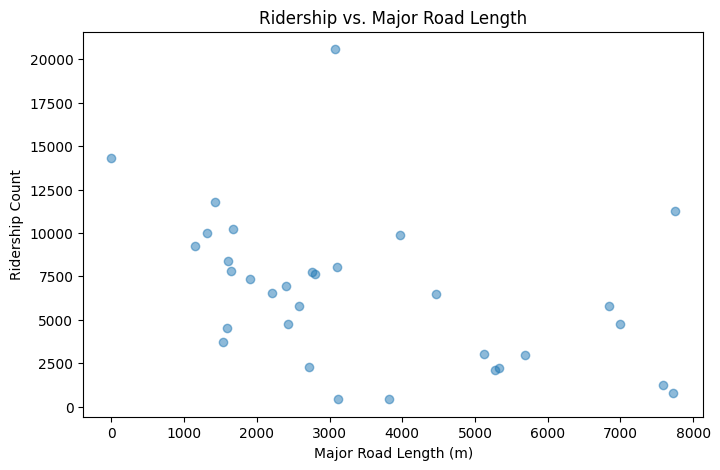

In [ ]:
# cluster 2 major road length
plt.figure(figsize=(8, 5))
plt.scatter(road_df2['major_road_length_m'], road_df2['combined_count'], alpha=0.5)
plt.xlabel('Major Road Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Major Road Length')
plt.show()

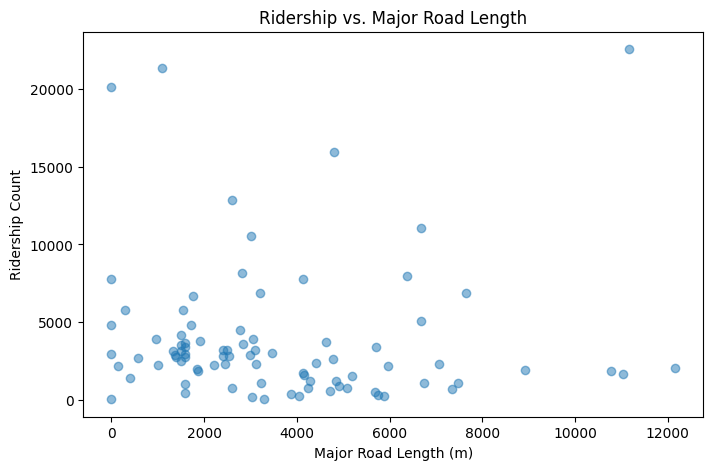

In [ ]:
# cluster 3 major road length
plt.figure(figsize=(8, 5))
plt.scatter(road_df3['major_road_length_m'], road_df3['combined_count'], alpha=0.5)
plt.xlabel('Major Road Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Major Road Length')
plt.show()

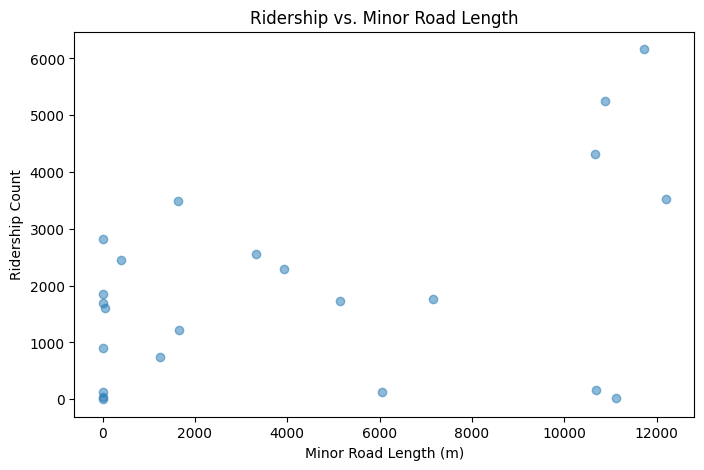

                     major_road_length_m  minor_road_length_m  combined_count
major_road_length_m             1.000000             0.596305        0.095692
minor_road_length_m             0.596305             1.000000        0.445397
combined_count                  0.095692             0.445397        1.000000


In [ ]:
# cluster 0 minor road length
plt.figure(figsize=(8, 5))
plt.scatter(road_df0['minor_road_length_m'], road_df0['combined_count'], alpha=0.5)
plt.xlabel('Minor Road Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Minor Road Length')
plt.show()
print(road_df0[['major_road_length_m', 'minor_road_length_m', 'combined_count']].corr())

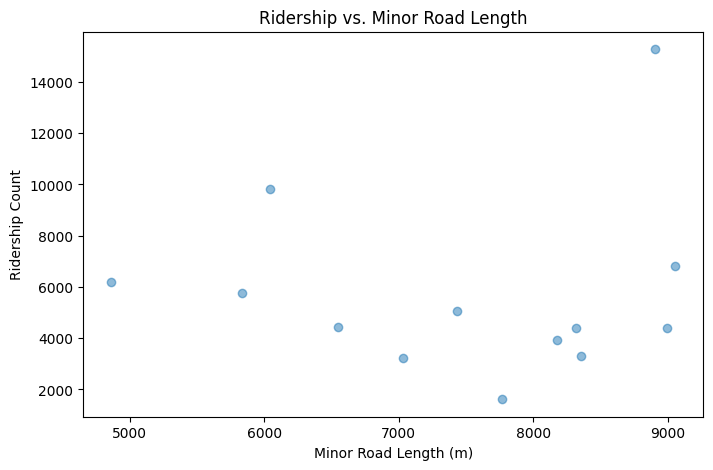

                     major_road_length_m  minor_road_length_m  combined_count
major_road_length_m             1.000000             0.211396       -0.060862
minor_road_length_m             0.211396             1.000000        0.050485
combined_count                 -0.060862             0.050485        1.000000


In [ ]:
# cluster 1 minor road length
plt.figure(figsize=(8, 5))
plt.scatter(road_df1['minor_road_length_m'], road_df1['combined_count'], alpha=0.5)
plt.xlabel('Minor Road Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Minor Road Length')
plt.show()
print(road_df1[['major_road_length_m', 'minor_road_length_m', 'combined_count']].corr())

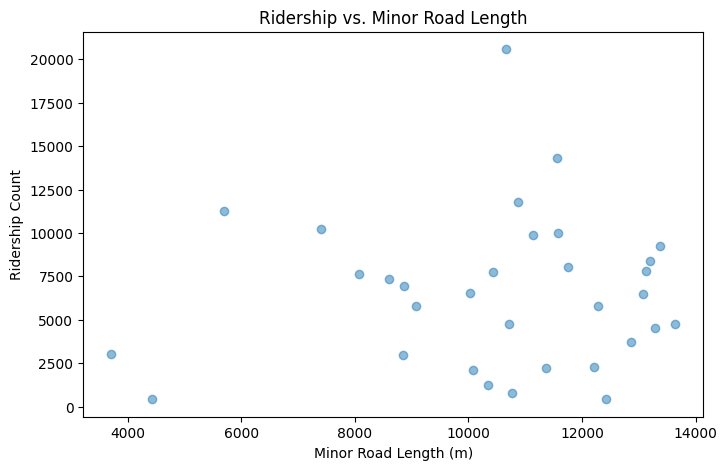

                     major_road_length_m  minor_road_length_m  combined_count
major_road_length_m             1.000000            -0.381966       -0.410366
minor_road_length_m            -0.381966             1.000000        0.067962
combined_count                 -0.410366             0.067962        1.000000


In [ ]:
# cluster 2 minor road length
plt.figure(figsize=(8, 5))
plt.scatter(road_df2['minor_road_length_m'], road_df2['combined_count'], alpha=0.5)
plt.xlabel('Minor Road Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Minor Road Length')
plt.show()
print(road_df2[['major_road_length_m', 'minor_road_length_m', 'combined_count']].corr())

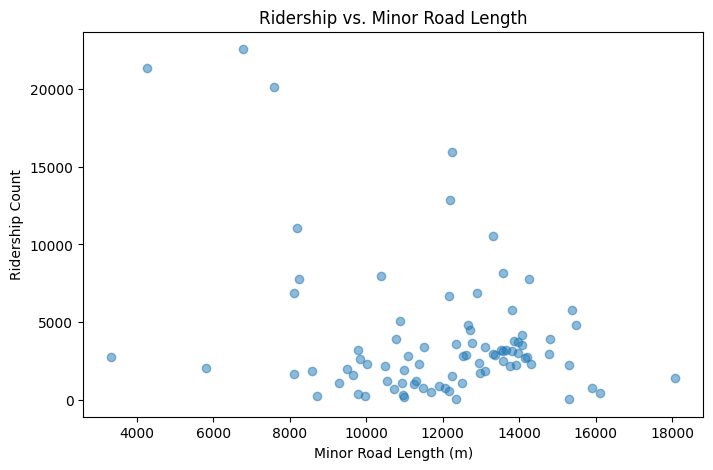

                     major_road_length_m  minor_road_length_m  combined_count
major_road_length_m             1.000000            -0.563727       -0.008335
minor_road_length_m            -0.563727             1.000000       -0.309362
combined_count                 -0.008335            -0.309362        1.000000


In [ ]:
# cluster 3 minor road length
plt.figure(figsize=(8, 5))
plt.scatter(road_df3['minor_road_length_m'], road_df3['combined_count'], alpha=0.5)
plt.xlabel('Minor Road Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Minor Road Length')
plt.show()
print(road_df3[['major_road_length_m', 'minor_road_length_m', 'combined_count']].corr())

In [ ]:
print(road_df[['major_road_length_m', 'minor_road_length_m', 'combined_count']].corr())


                     major_road_length_m  minor_road_length_m  combined_count
major_road_length_m             1.000000             0.031791        0.024356
minor_road_length_m             0.031791             1.000000        0.057876
combined_count                  0.024356             0.057876        1.000000


# Number of bikeshare stations in 800m buffer

In [59]:
stations_proj = stations.to_crs("EPSG:32610")
stations_proj['buffer_800'] = stations_proj.geometry.buffer(800)

# Count nearby stations for each station
nearby_counts = []
for idx, station in stations_proj.iterrows():
    buf = station['buffer_800']
    # Count how many stations fall within this buffer (excluding itself)
    count = stations_proj[stations_proj.geometry.within(buf)].shape[0] - 1
    nearby_counts.append({'id': station['id'], 'nearby_station_count': count})

nearby_df = pd.DataFrame(nearby_counts)

# Merge back
stations_proj = stations_proj.merge(nearby_df, on='id')
pd.set_option('display.max_rows', None)
stations_proj[['id', 'name', 'nearby_station_count']]

,id,name,nearby_station_count
0,BK-A3,College Ave at Alcatraz Ave,6
1,BK-A7,Vine St at Shattuck Ave,2
2,BK-B7,Virginia St at Shattuck Ave,5
3,BK-C1,Fifth St at Delaware St,2
4,BK-C5,North Berkeley BART,2
5,BK-C6,MLK Jr Way at University Ave,7
6,BK-C7,Shattuck Ave at Hearst Ave,8
7,BK-C8,University Ave at Oxford St,9
8,BK-C9,Euclid Ave at Hearst Ave,3
9,BK-D1,Addison St at Fourth St,2


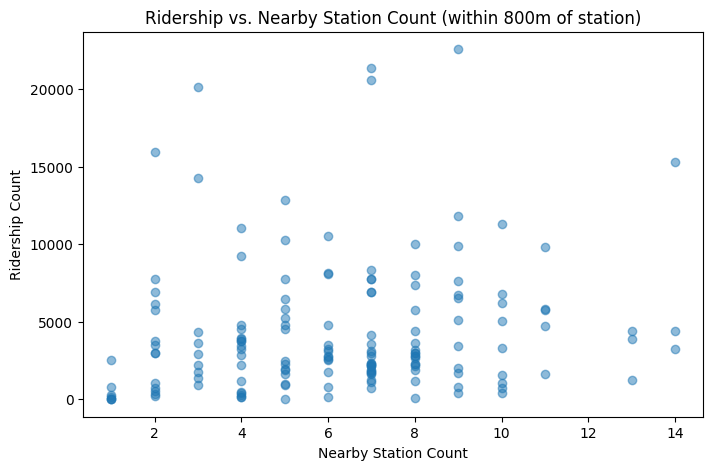

                      nearby_station_count  combined_count
nearby_station_count              1.000000        0.143892
combined_count                    0.143892        1.000000


In [60]:
plt.figure(figsize=(8, 5))
plt.scatter(stations_proj['nearby_station_count'], stations_proj['combined_count'], alpha=0.5)
plt.xlabel('Nearby Station Count')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Nearby Station Count (within 800m of station)')
plt.show()
print(stations_proj[['nearby_station_count', 'combined_count']].corr())

# Length of Bicycle Facility in 800m buffer

In [45]:
bike_network = gpd.read_file(DATA_FOLDER_PATH + 'regional_bike_facilities.geojson')
bike_network.head(30)

,objectid,class,geometry
0,1,3,"LINESTRING (-122.07222 37.57504, -122.07202 37..."
1,2,3,"LINESTRING (-122.07102 37.5969, -122.071 37.59..."
2,3,3,"LINESTRING (-122.07102 37.5969, -122.071 37.59..."
3,4,3,"LINESTRING (-122.06971 37.5852, -122.06957 37...."
4,5,3,"LINESTRING (-122.06414 37.94522, -122.06414 37..."
5,6,3,"LINESTRING (-122.13353 37.71068, -122.13221 37..."
6,7,2,"LINESTRING (-122.41094 37.71887, -122.4109 37...."
7,8,3,"LINESTRING (-122.06514 37.60734, -122.06503 37..."
8,9,3,"LINESTRING (-122.05496 37.70379, -122.05496 37..."
9,10,2,"LINESTRING (-122.41103 37.71906, -122.411 37.7..."


In [68]:
bike_lanes = bike_network.to_crs("EPSG:32610")

results = []
for idx, station in stations_proj.iterrows():
    buf = station['buffer_800']
    clipped = bike_lanes[bike_lanes.geometry.intersects(buf)].copy()
    clipped['geometry'] = clipped.geometry.intersection(buf)
    bike_lane_len = clipped['geometry'].length.sum()

    results.append({
        'id': station['id'],
        'name': station['name'],
        'cluster': station['cluster'],
        'combined_count': station['combined_count'],
        'bike_lane_length_m': bike_lane_len
    })

bike_df = pd.DataFrame(results)
print(bike_df.head())

      id                         name  cluster  combined_count  \
0  BK-A3  College Ave at Alcatraz Ave        3            3130   
1  BK-A7      Vine St at Shattuck Ave        2            7784   
2  BK-B7  Virginia St at Shattuck Ave        2            4536   
3  BK-C1      Fifth St at Delaware St        0            3523   
4  BK-C5          North Berkeley BART        3            5765   

   bike_lane_length_m  
0         4577.698095  
1         7591.321214  
2         7731.260412  
3         5400.204623  
4         7809.394364  


In [70]:
bike_df0 = bike_df[bike_df['cluster']==0]
bike_df1 = bike_df[bike_df['cluster']==1]
bike_df2 = bike_df[bike_df['cluster']==2]
bike_df3 = bike_df[bike_df['cluster']==3]

In [54]:
print(bike_lanes['class'].value_counts())

class
2    3582
3    2538
1    1103
Name: count, dtype: int64


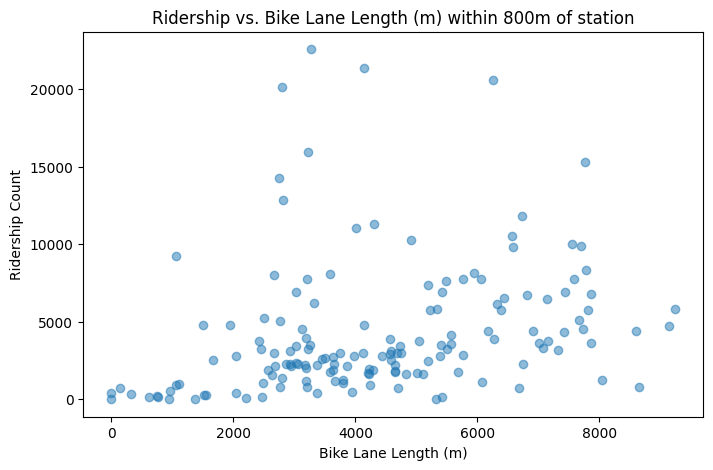

                    bike_lane_length_m  combined_count
bike_lane_length_m            1.000000        0.266041
combined_count                0.266041        1.000000


In [67]:
# All stations
plt.figure(figsize=(8, 5))
plt.scatter(bike_df['bike_lane_length_m'], bike_df['combined_count'], alpha=0.5)
plt.xlabel('Bike Lane Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Bike Lane Length (m) within 800m of station')
plt.show()
print(bike_df[['bike_lane_length_m', 'combined_count']].corr())

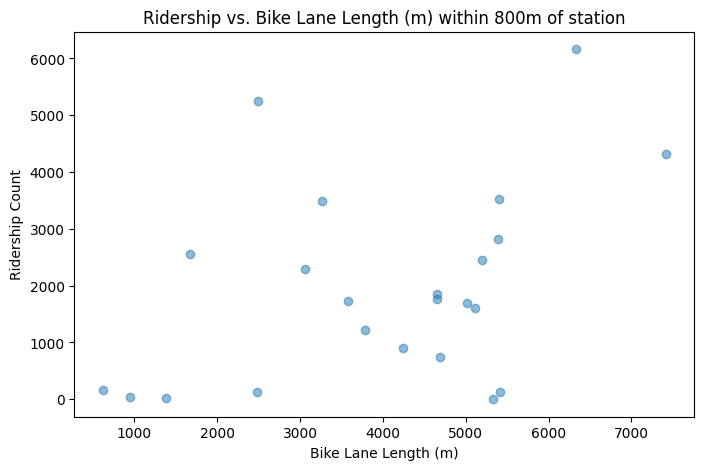

                    bike_lane_length_m  combined_count
bike_lane_length_m            1.000000        0.402066
combined_count                0.402066        1.000000


In [71]:
# cluster 0
plt.figure(figsize=(8, 5))
plt.scatter(bike_df0['bike_lane_length_m'], bike_df0['combined_count'], alpha=0.5)
plt.xlabel('Bike Lane Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Bike Lane Length (m) within 800m of station')
plt.show()
print(bike_df0[['bike_lane_length_m', 'combined_count']].corr())

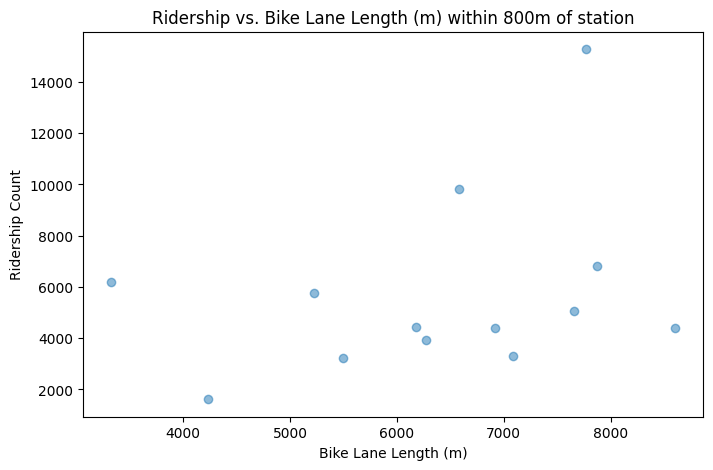

                    bike_lane_length_m  combined_count
bike_lane_length_m            1.000000        0.304981
combined_count                0.304981        1.000000


In [72]:
# cluster 1
plt.figure(figsize=(8, 5))
plt.scatter(bike_df1['bike_lane_length_m'], bike_df1['combined_count'], alpha=0.5)
plt.xlabel('Bike Lane Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Bike Lane Length (m) within 800m of station')
plt.show()
print(bike_df1[['bike_lane_length_m', 'combined_count']].corr())

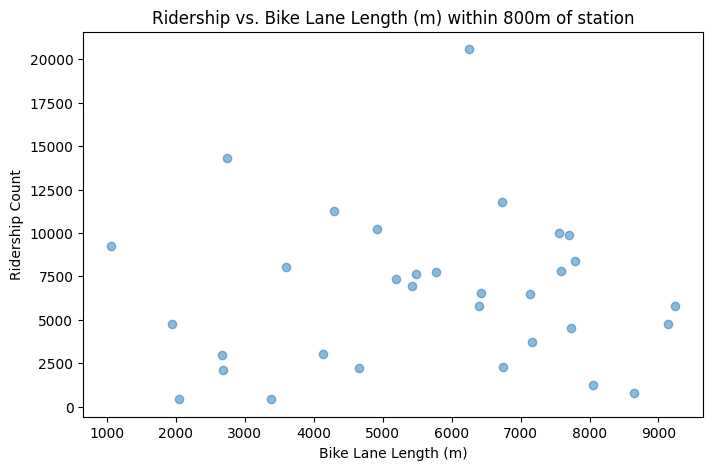

                    bike_lane_length_m  combined_count
bike_lane_length_m            1.000000        0.031036
combined_count                0.031036        1.000000


In [73]:
# cluster 2
plt.figure(figsize=(8, 5))
plt.scatter(bike_df2['bike_lane_length_m'], bike_df2['combined_count'], alpha=0.5)
plt.xlabel('Bike Lane Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Bike Lane Length (m) within 800m of station')
plt.show()
print(bike_df2[['bike_lane_length_m', 'combined_count']].corr())

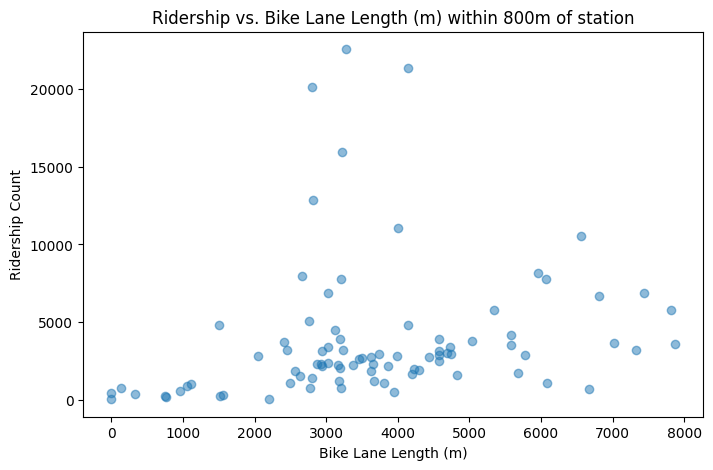

                    bike_lane_length_m  combined_count
bike_lane_length_m            1.000000        0.203494
combined_count                0.203494        1.000000


In [74]:
# cluster 3
plt.figure(figsize=(8, 5))
plt.scatter(bike_df3['bike_lane_length_m'], bike_df3['combined_count'], alpha=0.5)
plt.xlabel('Bike Lane Length (m)')
plt.ylabel('Ridership Count')
plt.title('Ridership vs. Bike Lane Length (m) within 800m of station')
plt.show()
print(bike_df3[['bike_lane_length_m', 'combined_count']].corr())

In [76]:
print(bike_df3.columns.tolist())
print(bike_df3.head())

['id', 'name', 'cluster', 'combined_count', 'bike_lane_length_m']
        id                         name  cluster  combined_count  \
0    BK-A3  College Ave at Alcatraz Ave        3            3130   
4    BK-C5          North Berkeley BART        3            5765   
10  BK-D10  Bancroft Way at College Ave        3           20131   
11   BK-D2   Ninth St at University Ave        3            2847   
12   BK-D4    West St at University Ave        3            3644   

    bike_lane_length_m  
0          4577.698095  
4          7809.394364  
10         2795.076702  
11         5771.362162  
12         7013.799902  


In [82]:
import plotly.express as px

cluster_labels = {
    1: 'Transit-Oriented Commercial Core',
    2: 'High Access Mixed Urban',
    3: 'Residential - Transit Access',
    0: 'Residential - Low Transit Access'
}

cluster_colors = {
    'Residential - Transit Access': '#F4A020',
    'High Access Mixed Urban': '#4A90D9',
    'Residential - Low Transit Access': '#E03030',
    'Transit-Oriented Commercial Core': '#3DB54A'
}

bike_df['typology'] = bike_df['cluster'].map(cluster_labels)

fig = px.scatter(
    bike_df,
    x='bike_lane_length_m',
    y='combined_count',
    color='typology',
    color_discrete_map=cluster_colors,
    hover_data=['name'],
    labels={
        'bike_lane_length_m': 'Bike Lane Length (m)',
        'combined_count': 'Ridership Count',
        'typology': 'Station Typology'
    },
    title='Ridership vs. Bike Lane Length by Station Typology'
)

# fig.write_html('ridership_vs_bike_lanes.html')
fig.show()

In [94]:
import plotly.express as px
import plotly.io as pio

cluster_labels = {
    3: 'Residential - Transit Access',
    2: 'High Access Mixed Urban',
    0: 'Residential - Low Transit Access',
    1: 'Transit-Oriented Commercial Core'
}

cluster_colors = {
    'Residential - Transit Access': '#F4A020',
    'High Access Mixed Urban': '#4A90D9',
    'Residential - Low Transit Access': '#E03030',
    'Transit-Oriented Commercial Core': '#3DB54A'
}

bike_df['typology'] = bike_df['cluster'].map(cluster_labels)

for cluster_num, typology_name in cluster_labels.items():
    cluster_df = bike_df[bike_df['cluster'] == cluster_num]
    color = cluster_colors[typology_name]

    fig = px.scatter(
        cluster_df,
        x='bike_lane_length_m',
        y='combined_count',
        hover_data=['name'],
        labels={
            'bike_lane_length_m': 'Bike Lane Length (m) in 800m buffer',
            'combined_count': 'Ridership Count',
        },
        title=f'{typology_name}'
    )

    fig.update_traces(marker=dict(color=color, size=8, opacity=0.7))
    corr = cluster_df['bike_lane_length_m'].corr(cluster_df['combined_count'])

    fig.add_annotation(
        x=0.05, y=0.95,
        xref='paper', yref='paper',
        text=f'r = {corr:.2f}',
        showarrow=False,
        font=dict(size=16),
        bgcolor='white'
    )
    fig.update_layout(
        plot_bgcolor='#fafaf7',
        # paper_bgcolor='#fafaf7'
    )
    config = {
        'displayModeBar': False
    }

    fig.show(config=config)

    filename = DATA_FOLDER_PATH + f'cleaned/ridership_bike_lanes_{typology_name.lower().replace(" ", "_").replace("-", "")}.html'
    fig.write_html(filename, config=config)
    print(f'Saved: {filename}')

Saved: /content/drive/MyDrive/255 Final Project/Data/cleaned/ridership_bike_lanes_residential__transit_access.html


Saved: /content/drive/MyDrive/255 Final Project/Data/cleaned/ridership_bike_lanes_high_access_mixed_urban.html


Saved: /content/drive/MyDrive/255 Final Project/Data/cleaned/ridership_bike_lanes_residential__low_transit_access.html


Saved: /content/drive/MyDrive/255 Final Project/Data/cleaned/ridership_bike_lanes_transitoriented_commercial_core.html
